Device: cpu

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [24:20<00:00, 117kB/s]


Dataset loaded successfully!
Number of training images: 1000

VAE model created successfully!
Epoch [1/5], Loss: 9729.9453
Epoch [2/5], Loss: 2908.2349
Epoch [3/5], Loss: 2336.5604
Epoch [4/5], Loss: 2014.8772
Epoch [5/5], Loss: 1786.0796


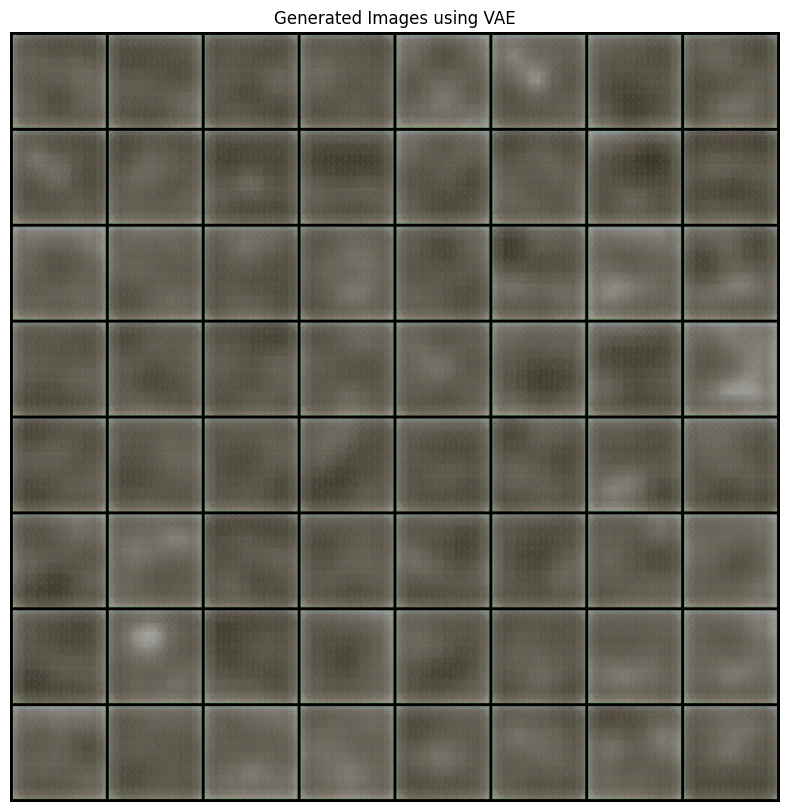


VAE IMAGE GENERATION RESULT
Dataset       : CIFAR-10
Images Used   : 1000
Image Size    : 64 x 64
Latent Dim    : 100
Epochs        : 5
Generated     : 64 images
Model         : Variational Autoencoder


In [1]:
# ============================================================
# EX 8: IMAGE GENERATION USING VARIATIONAL AUTOENCODER (VAE)
# AI23531 - Deep Learning
# Replacement version for Colab
# Dataset: CIFAR-10
# ============================================================

# ------------------------------------------------------------
# 1. Import Required Libraries
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2. Configure Parameters
# ------------------------------------------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

image_size = 64
batch_size = 64
latent_dim = 100
num_epochs = 5
learning_rate = 1e-3

print("Device:", device)

# ------------------------------------------------------------
# 3. Load CIFAR-10 Dataset
# ------------------------------------------------------------
# CIFAR-10 is used because CelebA's Google Drive download
# is currently unavailable in Google Colab.

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

print("\nLoading CIFAR-10 dataset...")

dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# Use only 1000 images for faster practical execution
dataset = Subset(dataset, range(1000))

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Dataset loaded successfully!")
print("Number of training images:", len(dataset))

# ------------------------------------------------------------
# 4. Define Encoder Network
# ------------------------------------------------------------
class Encoder(nn.Module):

    def __init__(self, latent_dim):
        super(Encoder, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(
            512 * 4 * 4,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            512 * 4 * 4,
            latent_dim
        )

    def forward(self, x):

        x = self.conv(x)

        x = x.view(x.size(0), -1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar


# ------------------------------------------------------------
# 5. Define Decoder Network
# ------------------------------------------------------------
class Decoder(nn.Module):

    def __init__(self, latent_dim):
        super(Decoder, self).__init__()

        self.fc = nn.Linear(
            latent_dim,
            512 * 4 * 4
        )

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(
                512, 256, 4, 2, 1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(
                256, 128, 4, 2, 1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64, 4, 2, 1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 3, 4, 2, 1
            ),
            nn.Tanh()
        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(
            x.size(0),
            512,
            4,
            4
        )

        return self.deconv(x)


# ------------------------------------------------------------
# 6. Define VAE Model
# ------------------------------------------------------------
class VAE(nn.Module):

    def __init__(self, latent_dim):
        super(VAE, self).__init__()

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # Reparameterization Trick
    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def forward(self, x):

        mu, logvar = self.encoder(x)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar


# ------------------------------------------------------------
# 7. Define VAE Loss Function
# ------------------------------------------------------------
def vae_loss(recon_x, x, mu, logvar):

    # Reconstruction Loss
    recon_loss = F.mse_loss(
        recon_x,
        x,
        reduction="sum"
    )

    # KL Divergence
    kl_div = -0.5 * torch.sum(
        1 + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    # Total Loss
    return recon_loss + kl_div


# ------------------------------------------------------------
# 8. Create VAE Model and Optimizer
# ------------------------------------------------------------
model = VAE(latent_dim).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("\nVAE model created successfully!")

# ------------------------------------------------------------
# 9. Train the VAE
# ------------------------------------------------------------
for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for images, _ in dataloader:

        images = images.to(device)

        # Forward pass
        recon, mu, logvar = model(images)

        # Calculate VAE loss
        loss = vae_loss(
            recon,
            images,
            mu,
            logvar
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss / len(dataloader.dataset)
    )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {average_loss:.4f}"
    )


# ------------------------------------------------------------
# 10. Generate New Images
# ------------------------------------------------------------
model.eval()

with torch.no_grad():

    # Generate random latent vectors
    z = torch.randn(
        64,
        latent_dim
    ).to(device)

    # Decode latent vectors
    sample_images = model.decoder(z).cpu()

    # Convert from [-1, 1] to [0, 1]
    sample_images = (
        sample_images * 0.5 + 0.5
    )


# ------------------------------------------------------------
# 11. Create Image Grid
# ------------------------------------------------------------
grid = torchvision.utils.make_grid(
    sample_images,
    nrow=8
)

plt.figure(figsize=(10, 10))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "Generated Images using VAE"
)

plt.show()


# ------------------------------------------------------------
# 12. Final Result
# ------------------------------------------------------------
print("\n===================================")
print("VAE IMAGE GENERATION RESULT")
print("===================================")
print("Dataset       : CIFAR-10")
print("Images Used   : 1000")
print("Image Size    : 64 x 64")
print("Latent Dim    :", latent_dim)
print("Epochs        :", num_epochs)
print("Generated     : 64 images")
print("Model         : Variational Autoencoder")
print("===================================")